# Stage 9: Pseudo-Cell Tokenization and GeneCompass Embedding

## Stage Objective

Represent Stage 8 pseudo-cells in the fine-tuned GeneCompass latent space and verify that the resulting embeddings preserve analyzable biological variation.

## Workflow

| Step | Operation | Analytical purpose |
|------|-----------|--------------------|
| 1 | Tokenization | Apply the Stage 5 rank-based procedure to pseudo-cell expression profiles. |
| 2 | Model inference | Generate 768-dimensional CLS embeddings with the Stage 7 rat model. |
| 3 | Alignment validation | Verify row-level correspondence among expression, metadata, tokenized records, and embeddings. |
| 4 | Quality gate | Use Augur AUC to assess whether treatment-related structure is detectable by tissue and cell type. |

## Inputs and Outputs

| Component | Description |
|-----------|-------------|
| Inputs | Stage 8 pseudo-cells, Stage 3 tokens, Stage 4 medians, and the Stage 7 model. |
| Primary outputs | Tokenized pseudo-cell datasets, aligned metadata, CLS embeddings, and Augur quality metrics. |

## Result Overview

The stage creates a reproducible embedding representation for downstream differential and supervised subspace analyses.

The sections below present the computational evidence in execution order. All reported figures are generated from the recorded stage outputs rather than manually entered plotting values unless explicitly identified as configuration constants.


In [1]:
import os, json
from pathlib import Path

PROJECT = Path("..")
GC_DIR  = PROJECT / "data/deconvolution/genecompass_input"
tissues = ["blood","cortex","heart","hippoc","kidney","liver","lung","skmgn","skmvl","watsc"]

print(f"{'Tissue':<10} {'dataset/':>12}  {'cell_embeddings.npy':>24}  {'tokenize_summary.json':>22}")
print("-" * 74)
total_emb = 0
for t in tissues:
    ds  = GC_DIR / t / "dataset"
    emb = GC_DIR / t / "embeddings" / "cell_embeddings.npy"
    tsj = GC_DIR / t / "tokenize_summary.json"
    n_shards = len(list(ds.glob("*.arrow"))) if ds.exists() else 0
    emb_mb   = emb.stat().st_size / 1e6 if emb.exists() else 0
    total_emb += emb_mb
    summary  = json.loads(tsj.read_text()) if tsj.exists() else {}
    n_cells  = summary.get("n_pseudocells", "?")
    print(f"{t:<10} {n_shards:>8} shards  {emb_mb:>16.1f} MB  ({n_cells} cells × 768 dims)")
print("-" * 74)
print(f"{'TOTAL':<10} {total_emb:>36.1f} MB  embeddings")


Tissue         dataset/       cell_embeddings.npy   tokenize_summary.json
--------------------------------------------------------------------------
blood             2 shards               2.2 MB  (700 cells × 768 dims)
cortex            1 shards               1.7 MB  (550 cells × 768 dims)
heart             1 shards               2.5 MB  (800 cells × 768 dims)
hippoc            1 shards               2.8 MB  (900 cells × 768 dims)
kidney            1 shards               2.6 MB  (850 cells × 768 dims)
liver             1 shards               0.9 MB  (300 cells × 768 dims)
lung              1 shards               4.3 MB  (1400 cells × 768 dims)
skmgn             1 shards               0.8 MB  (250 cells × 768 dims)
skmvl             5 shards               0.8 MB  (250 cells × 768 dims)
watsc             1 shards               2.0 MB  (650 cells × 768 dims)
--------------------------------------------------------------------------
TOTAL                                      20.4 MB  emb

## Step 1 — Tokenize Pseudo-cells

`tokenize_pseudocells.py` reuses the same tokenizer as Stage 5 (`pipeline/05_tokenization/tokenize_corpus.py`) with two key differences:

| Parameter | Stage 5 (training corpus) | Stage 9 (pseudo-cells) |
|-----------|--------------------------|------------------------|
| Input | Raw scRNA-seq counts | BayesPrism Z (count-scale) |
| `normalize_total` target | 10,000 | **6,500** (calibrated to Z values) |
| `top_n` | 2,048 | 2,048 |
| `species` | 2 (rat) | 2 (rat) |
| Gene space | GeneCompass rat vocabulary | Same |

**Why target_sum=6500?** BayesPrism posterior Z matrices have a different absolute count scale than raw scRNA-seq counts. target_sum=6500 was chosen so the normalized value distribution of pseudo-cells (median ~0.88–1.07) matches the training corpus reference (median 0.869, mean 0.960), ensuring the tokenizer rank-encodes pseudo-cells in the same semantic space as training.

The `tokenize_summary.json` written per tissue records: number of cells, eligible genes, value distribution statistics, and mean expressed sequence length (expected tokens per cell after rank-top-2048).


In [2]:
import json, pandas as pd
from pathlib import Path

GC_DIR  = Path("../data/deconvolution/genecompass_input")
tissues = ["blood","cortex","heart","hippoc","kidney","liver","lung","skmgn","skmvl","watsc"]

# Tokenize details from SLURM logs (tokenize_pseudocells.py stdout)
min_len = {
    "blood":700,"cortex":1180,"heart":1065,"hippoc":1805,
    "kidney":1086,"liver":1318,"lung":433,"skmgn":627,"skmvl":459,"watsc":424
}

rows = []
for t in tissues:
    f = GC_DIR / t / "tokenize_summary.json"
    s = json.loads(f.read_text()) if f.exists() else {}
    rows.append({
        "tissue":        t,
        "cells":         s.get("n_pseudocells",     "?"),
        "eligible genes":s.get("n_eligible_genes",  "?"),
        "median value":  round(s.get("value_stats",{}).get("median", float("nan")), 3),
        "p90 value":     round(s.get("value_stats",{}).get("p90",    float("nan")), 3),
        "mean tok len":  round(s.get("mean_expressed_length", float("nan")), 1),
        "min tok len":   min_len.get(t, "?"),
    })

df = pd.DataFrame(rows)
print(df.to_string(index=False))
print()
print("Corpus reference (Stage 5): median=0.869, mean=0.960")
print("All tissues: top_n=2048, target_sum=6500, species=2, 0 cells dropped (< 200 genes)")


tissue  cells  eligible genes  median value  p90 value  mean tok len  min tok len
 blood    700           11305         0.881      2.286        1718.0          700
cortex    550           15402         0.938      1.867        2027.1         1180
 heart    800           15864         0.861      1.803        2015.1         1065
hippoc    900           15523         1.014      1.982        2033.0         1805
kidney    850           14952         1.068      1.978        2005.3         1086
 liver    300           12759         0.870      1.800        2042.5         1318
  lung   1400           15233         1.013      1.905        1960.8          433
 skmgn    250           13144         0.788      1.774        2048.0          627
 skmvl    250           13143         0.807      1.804        2048.0          459
 watsc    650           12890         0.866      1.716        2032.5          424

Corpus reference (Stage 5): median=0.869, mean=0.960
All tissues: top_n=2048, target_sum=6500, sp

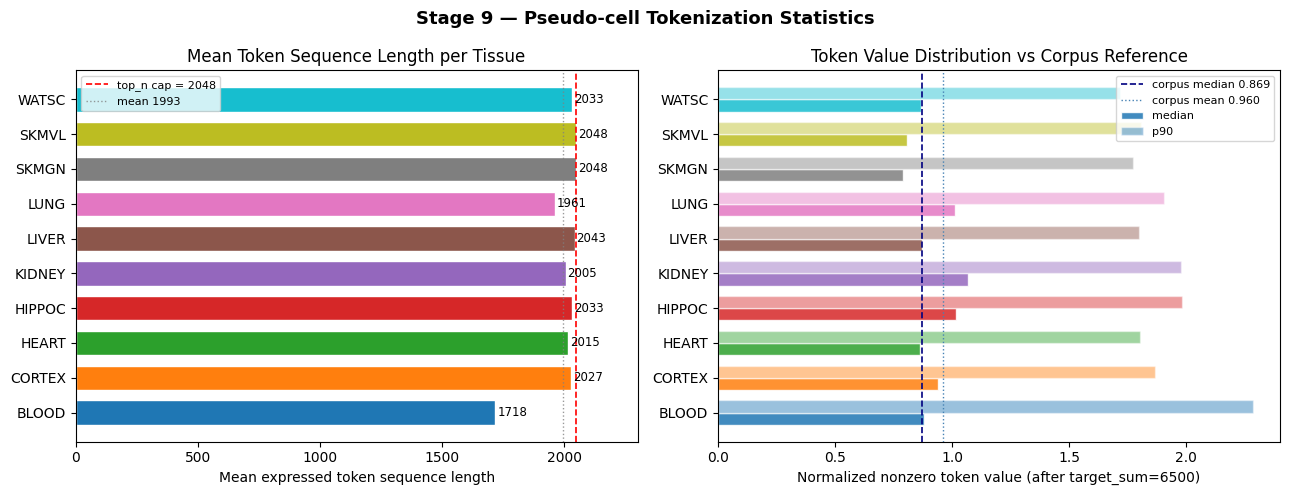

In [3]:
import json, numpy as np, matplotlib.pyplot as plt
from pathlib import Path

GC_DIR  = Path("../data/deconvolution/genecompass_input")
tissues = ["blood","cortex","heart","hippoc","kidney","liver","lung","skmgn","skmvl","watsc"]

mean_len, median_val, p90_val = [], [], []
for t in tissues:
    s = json.loads((GC_DIR / t / "tokenize_summary.json").read_text())
    mean_len.append(s["mean_expressed_length"])
    median_val.append(s["value_stats"]["median"])
    p90_val.append(s["value_stats"]["p90"])

colors = plt.cm.tab10(np.linspace(0, 1, len(tissues)))
y = np.arange(len(tissues))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Stage 9 — Pseudo-cell Tokenization Statistics", fontsize=13, fontweight="bold")

# Left: mean expressed sequence length
bars = ax1.barh(y, mean_len, color=colors, edgecolor="white", height=0.7)
ax1.axvline(2048, color="red", lw=1.2, ls="--", label="top_n cap = 2048")
ax1.axvline(np.mean(mean_len), color="gray", lw=1, ls=":", alpha=0.8,
            label=f"mean {np.mean(mean_len):.0f}")
for bar, v in zip(bars, mean_len):
    ax1.text(v + 8, bar.get_y() + bar.get_height()/2,
             f"{v:.0f}", va="center", fontsize=8.5)
ax1.set_yticks(y)
ax1.set_yticklabels([t.upper() for t in tissues])
ax1.set_xlabel("Mean expressed token sequence length")
ax1.set_title("Mean Token Sequence Length per Tissue")
ax1.set_xlim(0, 2300)
ax1.legend(fontsize=8)

# Right: value stats per tissue (median + p90)
width = 0.35
bars2 = ax2.barh(y - width/2, median_val, width, label="median",
                 color=colors, edgecolor="white", alpha=0.85)
bars3 = ax2.barh(y + width/2, p90_val, width, label="p90",
                 color=colors, edgecolor="white", alpha=0.45)
ax2.axvline(0.869, color="navy", lw=1.2, ls="--", label="corpus median 0.869")
ax2.axvline(0.960, color="steelblue", lw=1, ls=":", label="corpus mean 0.960")
ax2.set_yticks(y)
ax2.set_yticklabels([t.upper() for t in tissues])
ax2.set_xlabel("Normalized nonzero token value (after target_sum=6500)")
ax2.set_title("Token Value Distribution vs Corpus Reference")
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()


## Step 2 — GeneCompass CLS Embedding (GPU)

`embed_cells.py` loads the fine-tuned rat GeneCompass model (Stage 7, `checkpoint-147941` of Phase 2) and runs inference on the tokenized dataset to extract **CLS embeddings**:

| Property | Value |
|----------|-------|
| Model | Rat GeneCompass (Stage 7 Phase 2 final) |
| Architecture | BERT 12L-768d, 12 attention heads, context 2048 |
| Embedding | Position-0 (CLS) hidden state, layer 12 |
| Embedding dim | **768** |
| Species token | 2 (rat) |
| Device | CUDA (GPU, Gilbreth) |
| Output dtype | float32 numpy array |
| Output layout | Row = one pseudo-cell; row order = `pseudocells.h5ad` obs order |

The CLS token aggregates information from all 2048 gene tokens in the sequence via 12 layers of multi-head self-attention. Its 768-d representation captures the cell's transcriptional state in the GeneCompass learned embedding space, informed by all four prior-knowledge channels (co-expression, gene family, promoter, GRN) embedded during Stage 6.

**Row alignment note:** `embed_cells.py` preserves the row order of `pseudocells.h5ad`. The `--n-cells` flag is set to the full pseudo-cell count (never subsampled), so `cell_embeddings.npy[i, :]` corresponds to `pseudocells.h5ad.obs.iloc[i]`.


In [4]:
import numpy as np
from pathlib import Path

GC_DIR  = Path("../data/deconvolution/genecompass_input")
tissues = ["blood","cortex","heart","hippoc","kidney","liver","lung","skmgn","skmvl","watsc"]

print(f"{'Tissue':<10} {'Shape':>16}  {'File (MB)':>12}  {'L2 norm (mean)':>16}  {'Std (dim mean)':>16}")
print("-" * 76)
total_cells = 0
for t in tissues:
    f = GC_DIR / t / "embeddings" / "cell_embeddings.npy"
    if not f.exists():
        print(f"{t:<10}  MISSING")
        continue
    emb = np.load(f)
    l2  = np.linalg.norm(emb, axis=1).mean()
    std = emb.std(axis=0).mean()
    total_cells += emb.shape[0]
    print(f"{t:<10} {str(emb.shape):>16}  {f.stat().st_size/1e6:>10.1f} MB"
          f"  {l2:>14.3f}  {std:>14.4f}")
print("-" * 76)
print(f"{'TOTAL':<10} {total_cells:>10,} cells × 768 dims")


Tissue                Shape     File (MB)    L2 norm (mean)    Std (dim mean)
----------------------------------------------------------------------------
blood            (700, 768)         2.2 MB          20.178          0.0742
cortex           (550, 768)         1.7 MB          20.255          0.0743
heart            (800, 768)         2.5 MB          20.169          0.0548
hippoc           (900, 768)         2.8 MB          20.245          0.0576
kidney           (850, 768)         2.6 MB          20.242          0.0653
liver            (300, 768)         0.9 MB          20.230          0.0518


lung            (1400, 768)         4.3 MB          20.209          0.0711
skmgn            (250, 768)         0.8 MB          20.191          0.0504
skmvl            (250, 768)         0.8 MB          20.186          0.0500
watsc            (650, 768)         2.0 MB          20.178          0.0625
----------------------------------------------------------------------------
TOTAL           6,650 cells × 768 dims


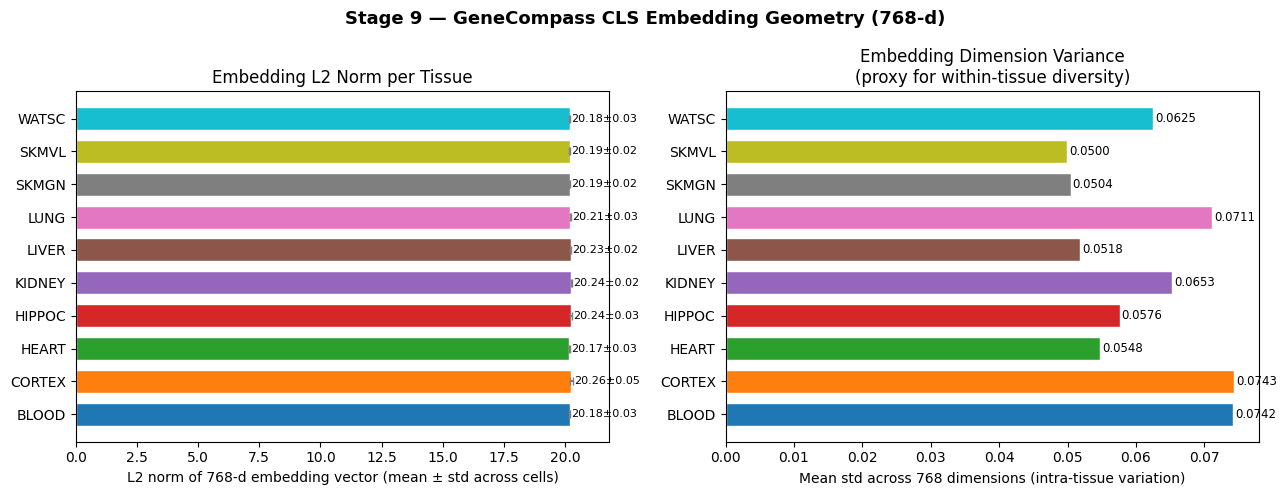

In [5]:
import numpy as np, matplotlib.pyplot as plt
from pathlib import Path

GC_DIR  = Path("../data/deconvolution/genecompass_input")
tissues = ["blood","cortex","heart","hippoc","kidney","liver","lung","skmgn","skmvl","watsc"]

l2_means, l2_stds, dim_stds = [], [], []
for t in tissues:
    emb = np.load(GC_DIR / t / "embeddings" / "cell_embeddings.npy")
    l2  = np.linalg.norm(emb, axis=1)
    l2_means.append(l2.mean())
    l2_stds.append(l2.std())
    dim_stds.append(emb.std(axis=0).mean())

colors = plt.cm.tab10(np.linspace(0, 1, len(tissues)))
y = np.arange(len(tissues))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Stage 9 — GeneCompass CLS Embedding Geometry (768-d)", fontsize=13, fontweight="bold")

# Left: L2 norm per tissue (mean ± std)
ax1.barh(y, l2_means, xerr=l2_stds, color=colors, edgecolor="white",
         height=0.7, error_kw=dict(ecolor="gray", capsize=3))
for i, (m, s) in enumerate(zip(l2_means, l2_stds)):
    ax1.text(m + s + 0.05, i, f"{m:.2f}±{s:.2f}", va="center", fontsize=8)
ax1.set_yticks(y)
ax1.set_yticklabels([t.upper() for t in tissues])
ax1.set_xlabel("L2 norm of 768-d embedding vector (mean ± std across cells)")
ax1.set_title("Embedding L2 Norm per Tissue")
ax1.set_xlim(0, max(l2_means) + max(l2_stds) + 1.5)

# Right: mean standard deviation across 768 dimensions
bars2 = ax2.barh(y, dim_stds, color=colors, edgecolor="white", height=0.7)
for bar, v in zip(bars2, dim_stds):
    ax2.text(v + 0.0003, bar.get_y() + bar.get_height()/2,
             f"{v:.4f}", va="center", fontsize=8.5)
ax2.set_yticks(y)
ax2.set_yticklabels([t.upper() for t in tissues])
ax2.set_xlabel("Mean std across 768 dimensions (intra-tissue variation)")
ax2.set_title("Embedding Dimension Variance\n(proxy for within-tissue diversity)")

plt.tight_layout()
plt.show()


## Embedding Quality Gate — Augur AUC

After embedding, the Aim 2 gate checks whether the GeneCompass embeddings carry biologically meaningful signal by running **Augur** (Skinnider et al. 2021) per tissue × cell type × condition. Augur trains a random forest to distinguish two groups within a 768-d embedding subspace, returning an AUC where:

- **AUC = 0.5** → embeddings are uninformative for this contrast
- **AUC → 1.0** → embeddings cleanly separate the groups

Two conditions are tested:
| Condition | Groups |
|-----------|--------|
| `trained` | trained exercise vs. sedentary control |
| `sex` | male vs. female |

The `pca_control.tsv` compares three representations for the same Augur task:
| Representation | Description |
|----------------|-------------|
| `embed` | 768-d GeneCompass CLS (Stage 9 output) |
| `pca` | Top-50 PCA of the same pseudo-cells (raw Z counts) |
| `genes` | Direct gene expression (raw Z, top-500 HVG) |

An `auc_embed > auc_pca ≥ auc_genes` pattern would indicate the GeneCompass embedding adds discriminative power beyond linear dimensionality reduction of the same data.


/tmp/ipykernel_3375069/2516104696.py:27: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(row.augur_auc) if len(row) else float("nan")


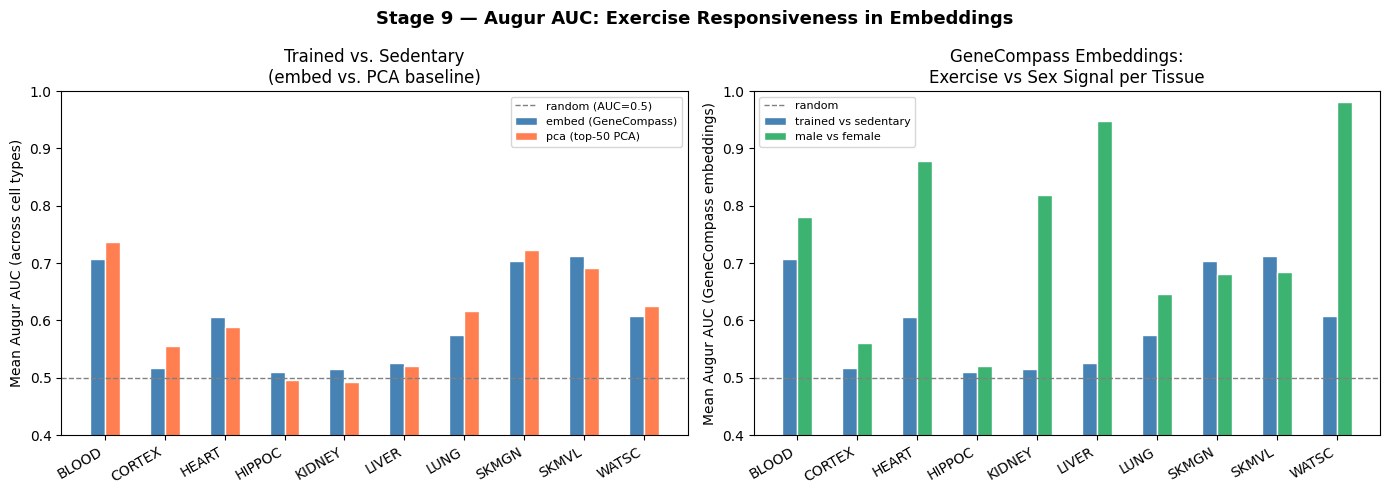

In [6]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from pathlib import Path

GC_DIR = Path("../data/deconvolution/genecompass_input")
df = pd.read_csv(GC_DIR / "augur_results.tsv", sep="\t")

# Focus on embed representation, trained condition
embed_trained = (
    df[(df.representation == "embed") & (df.condition == "trained")]
    .groupby("tissue")["augur_auc"].mean()
    .reset_index()
)
embed_sex = (
    df[(df.representation == "embed") & (df.condition == "sex")]
    .groupby("tissue")["augur_auc"].mean()
    .reset_index()
)
pca_trained = (
    df[(df.representation == "pca") & (df.condition == "trained")]
    .groupby("tissue")["augur_auc"].mean()
    .reset_index()
)

tissues_ord = ["blood","cortex","heart","hippoc","kidney","liver","lung","skmgn","skmvl","watsc"]
def get_auc(sub, t):
    row = sub[sub.tissue == t]
    return float(row.augur_auc) if len(row) else float("nan")

embed_t = [get_auc(embed_trained, t) for t in tissues_ord]
embed_s = [get_auc(embed_sex,     t) for t in tissues_ord]
pca_t   = [get_auc(pca_trained,   t) for t in tissues_ord]

x = np.arange(len(tissues_ord))
w = 0.25

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Stage 9 — Augur AUC: Exercise Responsiveness in Embeddings", fontsize=13, fontweight="bold")

# Left: embed vs pca for trained condition
ax1.bar(x - w/2, embed_t, w, label="embed (GeneCompass)", color="steelblue", edgecolor="white")
ax1.bar(x + w/2, pca_t,   w, label="pca (top-50 PCA)",    color="coral",     edgecolor="white")
ax1.axhline(0.5, color="gray", ls="--", lw=1, label="random (AUC=0.5)")
ax1.set_xticks(x)
ax1.set_xticklabels([t.upper() for t in tissues_ord], rotation=30, ha="right")
ax1.set_ylabel("Mean Augur AUC (across cell types)")
ax1.set_title("Trained vs. Sedentary\n(embed vs. PCA baseline)")
ax1.set_ylim(0.4, 1.0)
ax1.legend(fontsize=8)

# Right: embed trained vs sex (within embed representation)
ax2.bar(x - w/2, embed_t, w, label="trained vs sedentary", color="steelblue",  edgecolor="white")
ax2.bar(x + w/2, embed_s, w, label="male vs female",        color="mediumseagreen", edgecolor="white")
ax2.axhline(0.5, color="gray", ls="--", lw=1, label="random")
ax2.set_xticks(x)
ax2.set_xticklabels([t.upper() for t in tissues_ord], rotation=30, ha="right")
ax2.set_ylabel("Mean Augur AUC (GeneCompass embeddings)")
ax2.set_title("GeneCompass Embeddings:\nExercise vs Sex Signal per Tissue")
ax2.set_ylim(0.4, 1.0)
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()


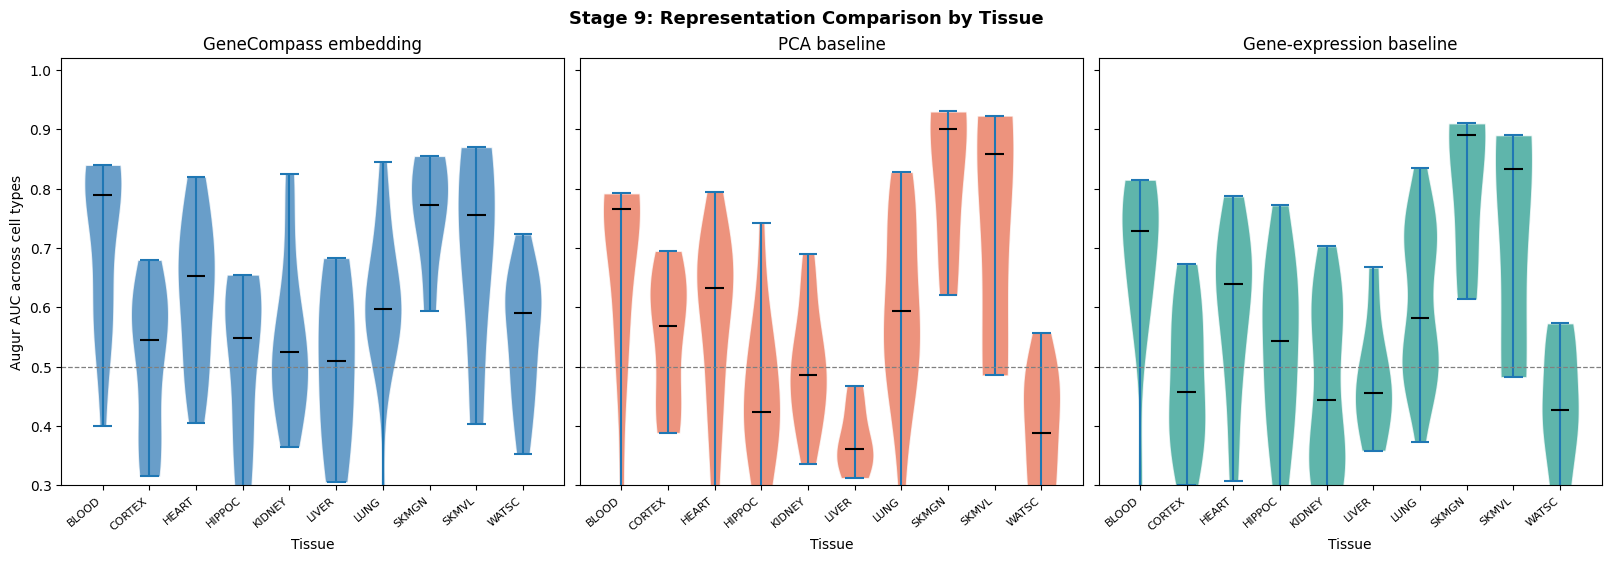

In [7]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from pathlib import Path

GC_DIR = Path("../data/deconvolution/genecompass_input")
pc = pd.read_csv(GC_DIR / "pca_control.tsv", sep="\t")
tissues_ord = ["blood","cortex","heart","hippoc","kidney","liver","lung","skmgn","skmvl","watsc"]
representations = [
    ("auc_embed", "GeneCompass embedding", "#377eb8"),
    ("auc_pca", "PCA baseline", "#e76f51"),
    ("auc_genes", "Gene-expression baseline", "#2a9d8f"),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5.5), sharey=True, constrained_layout=True)
fig.suptitle("Stage 9: Representation Comparison by Tissue", fontsize=13, fontweight="bold")

for ax, (column, title, color) in zip(axes, representations):
    data = [pc.loc[pc.tissue == tissue, column].dropna().values for tissue in tissues_ord]
    parts = ax.violinplot(data, positions=np.arange(len(tissues_ord)), showmedians=True, widths=0.8)
    for body in parts["bodies"]:
        body.set_facecolor(color); body.set_edgecolor("white"); body.set_alpha(0.75)
    parts["cmedians"].set_color("black")
    ax.axhline(0.5, color="gray", ls="--", lw=0.9)
    ax.set_xticks(np.arange(len(tissues_ord)))
    ax.set_xticklabels([t.upper() for t in tissues_ord], rotation=40, ha="right", fontsize=8)
    ax.set_title(title)
    ax.set_xlabel("Tissue")
    ax.set_ylim(0.3, 1.02)
axes[0].set_ylabel("Augur AUC across cell types")
plt.show()


## Stage Summary

Stage 9 tokenizes the pseudo-cells with the same ranking semantics used for model training, embeds them with the rat GeneCompass checkpoint, and verifies row alignment. Augur diagnostics provide an independent measure of treatment-signal recoverability.


## Reproducibility Notes

### SLURM Job History

Stages 8 and 9 ran in the same tissue-specific jobs. The adopted liver and lung outputs were regenerated in jobs **11170761** and **11171098**, respectively. Liver uses the Visium-excluded GSE220075 reference; lung uses the native pooled reference and replaces the earlier GSE178405 result. The remaining tissues retain the June 10 production runs (jobs 11002629-11002678).

### Key Hyperparameters

`target_sum=6500`, `top_n=2048`, rat species identifier `2`, final-layer 768-dimensional CLS embedding, and no pseudo-cell subsampling.

### Re-run Commands

```bash
python pipeline/run_stage9.py --label liver --device cuda
python pipeline/run_stage9.py --label lung --device cuda
```

Tokenization and inference are deterministic for fixed inputs, model weights, software, and hardware. Row `i` in `cell_embeddings.npy` corresponds to row `i` in `pseudocells.h5ad.obs`.


In [8]:
import numpy as np, json, hashlib
from pathlib import Path

GC_DIR  = Path("../data/deconvolution/genecompass_input")
tissues = ["blood","cortex","heart","hippoc","kidney","liver","lung","skmgn","skmvl","watsc"]

print("=== cell_embeddings.npy inventory ===")
all_ok = True
total_cells = 0
for t in tissues:
    emb_f = GC_DIR / t / "embeddings" / "cell_embeddings.npy"
    tok_f = GC_DIR / t / "tokenize_summary.json"
    if not emb_f.exists():
        print(f"  {t:<8}  MISSING embedding")
        all_ok = False
        continue
    emb = np.load(emb_f)
    expected_n = json.loads(tok_f.read_text())["n_pseudocells"] if tok_f.exists() else "?"
    shape_ok = "OK" if emb.shape[1] == 768 and emb.shape[0] == expected_n else "SHAPE MISMATCH"
    total_cells += emb.shape[0]
    md5 = hashlib.md5(emb_f.read_bytes()).hexdigest()
    print(f"  {t:<8}  {emb.shape[0]:>5,} x 768  [{shape_ok}]  md5={md5[:12]}...")

print(f"\nTotal embedded cells: {total_cells:,}")

print("\n=== tokenize_summary.json checksums ===")
for t in tissues:
    f = GC_DIR / t / "tokenize_summary.json"
    if f.exists():
        md5 = hashlib.md5(f.read_bytes()).hexdigest()
        print(f"  {t:<8}  {md5}")

print(f"\nAll outputs present: {all_ok}")


=== cell_embeddings.npy inventory ===
  blood       700 x 768  [OK]  md5=0b81cef7e428...
  cortex      550 x 768  [OK]  md5=1aad0f45f4c1...
  heart       800 x 768  [OK]  md5=dada0f477c7b...
  hippoc      900 x 768  [OK]  md5=01dabcc161e0...
  kidney      850 x 768  [OK]  md5=3c905ef4c707...
  liver       300 x 768  [OK]  md5=10cb25a3db1a...
  lung      1,400 x 768  [OK]  md5=566892889e94...
  skmgn       250 x 768  [OK]  md5=27020eb46d59...
  skmvl       250 x 768  [OK]  md5=d01f1dfde951...
  watsc       650 x 768  [OK]  md5=e8b99e05e37f...

Total embedded cells: 6,650

=== tokenize_summary.json checksums ===
  blood     edc622efd5d11f873848ca13eb999cb2
  cortex    19be1a478c8c4201ad2d4a905f476b2c
  heart     64d1071f5b9da3a328f4be2ca223c085
  hippoc    892d3335c577d2b9f08ea57cb260d2dd
  kidney    0fd1d6554af2b75a91da165ad4875453
  liver     3d8ef9901169987814f60ffc927ffabc
  lung      5424f0b964d6e44c6493c7e114c34d70
  skmgn     1249a1d16723e8c4e7a3696a5db60727
  skmvl     abc4746186